# Model Output Notebook

<img style="float:center;" src="https://arcticexpansion.vse.gmu.edu/sites/arcticexpansion.vsnet.gmu.edu/files/images/header5d2.png" width=600px>

### ADCIRC-SWAN Output


### Initialize Libraries

In [1]:
import warnings;            import os
import pathlib as pl;       import string
import calendar;            import numpy as np
import pandas as pd;        import xarray as xr
import ruptures as rpt;     import matplotlib.pyplot as plt
import matplotlib as mpl;   import cartopy.crs as ccrs
import cartopy.feature as cfeature
from dask.distributed import Client, LocalCluster
from scipy.stats import pearsonr, genextreme, gumbel_r
from statsmodels.tsa.stattools import adfuller, kpss
from dask import delayed
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tools.sm_exceptions import HypothesisTestWarning
warnings.filterwarnings("ignore")

source $HOME/miniforge3/bin/activate

salloc --ntasks=5 --nodes=1 --partition=normal --time=10:00:00

### Defined Functions

#### Data for this exercise can be found here
https://doi.org/10.17603/ds2-h0fw-2p96

Download the swan_HS.63.nc from one of the 4 folders

---

In [2]:
def compute_keep_idx(sample_path, min_depth, max_depth, bbox=None):
    """
    Return indices of nodes whose depth ∈ [min_depth, max_depth],
    optionally also within (min_x, max_x, min_y, max_y).
    """
    ds = xr.open_dataset(sample_path, engine="netcdf4", mask_and_scale=False)
    depth = ds.depth.values
    fv    = ds.depth.encoding.get("_FillValue", None)

    mask = np.ones_like(depth, dtype=bool)
    if fv is not None:
        mask &= (depth != fv)
    mask &= (depth >= min_depth) & (depth <= max_depth)

    if bbox is not None:
        min_x, max_x, min_y, max_y = bbox
        x, y = ds.x.values, ds.y.values
        mask &= (x >= min_x) & (x <= max_x) & (y >= min_y) & (y <= max_y)

    ds.close()
    return np.where(mask)[0]


def preprocess(ds):
    """Keep only the spin‑up‑free calendar year & shallow nodes."""
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    year = ds.time.dt.year.values[600]
    mask = ds.time.dt.year == year
    return ds.isel(time=mask, node=keep_idx)


# ─── Change-point detection function ──────────────────────────────────────────
def detect_cp_annual(y, years_array, n_bkps=1):
    """
    Identify one change-point in a 1D annual series using ruptures.
    Returns the corresponding year or NaN if no valid break.
    """
    # need at least 5 valid points
    if np.sum(~np.isnan(y)) < 5:
        return np.nan

    algo = rpt.Binseg(model='rbf').fit(y.reshape(-1, 1))
    bkps = algo.predict(n_bkps=n_bkps)  # e.g., [idx]
    cp   = bkps[0]

    # ensure break is interior
    if 0 < cp < len(years_array):
        return years_array[cp]
    return np.nan

def test_stationarity(arr, alpha=0.05):
    """
    Returns (is_stationary, p_adf, p_kpss) for a 1D array.
    ADF stationary if p_adf < alpha; KPSS stationary if p_kpss > alpha.
    """
    # ADF
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", HypothesisTestWarning)
        try:
            p_adf = adfuller(arr, autolag='AIC')[1]
        except Exception:
            p_adf = 0.0
    # KPSS
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", HypothesisTestWarning)
        try:
            p_kpss = kpss(arr, regression='c', nlags='auto')[1]
        except Exception:
            p_kpss = 1.0

    p_adf  = min(max(p_adf, 0.0), 1.0)
    p_kpss = min(max(p_kpss, 0.0), 1.0)
    return (p_adf < alpha) and (p_kpss > alpha), p_adf, p_kpss


def make_labels(n):
    """Generate ‘a.’, ‘b.’ … ‘z.’, ‘aa.’, … for n panels."""
    labels = []
    alphabet = string.ascii_lowercase
    i = 0
    while len(labels) < n:
        s, x = '', i
        while True:
            s = alphabet[x % 26] + s
            x = x // 26 - 1
            if x < 0:
                break
        labels.append(s + '.')
        i += 1
    return labels


In [ ]:
# ─── User‑set parameters ──────────────────────────────────────────────────────
lat1, lat2 = 56, 75
lon1, lon2 = -168.5, -140
root       = '/scratch/tmiesse/project/data4spatial'
YEARS      = range(1980, 2025)
MIN_DEPTH  = 10
MAX_DEPTH  = 15
bbox       = (lon1, lon2, lat1, lat2)

# compute shallow nodes index
sample_path = f"{root}/2023/swan_HS.63.cf.nc"
keep_idx    = compute_keep_idx(sample_path, MIN_DEPTH, MAX_DEPTH, bbox)
print(f"Keeping {len(keep_idx)} nodes")

Keeping 268300 nodes


In [4]:
from dask import delayed, compute
# ─── Spin up a Dask cluster ───────────────────────────────────────────────────
n_workers   = int(os.environ.get("SLURM_NTASKS", "45"))
mem_per_cpu = os.environ.get("SLURM_MEM_PER_CPU", "72GB")
cluster     = LocalCluster(
    n_workers=n_workers,
    threads_per_worker=1,
    processes=True,
    memory_limit=mem_per_cpu)
client = Client(cluster)
print(client)

<Client: 'tcp://127.0.0.1:37935' processes=45 threads=45, memory=2.95 TiB>


In [15]:
client.close()

In [5]:
paths = [str(pl.Path(root)/str(y)/"swan_HS.63.cf.nc") for y in YEARS]
ds_all = xr.open_mfdataset(
    paths,
    engine="h5netcdf",
    mask_and_scale=True,
    decode_cf=True,
    preprocess=preprocess,
    combine="nested",
    concat_dim="time",
    data_vars=['swan_HS'],               # only load zeta
    chunks={'time': 24},# chunk on both dims
    coords="minimal")   # minimal coords → time, node, x, y

times  = ds_all.time.values      # length T
hs = ds_all.swan_HS.values
x_all  = ds_all.x.values       # (n_nodes,)
y_all  = ds_all.y.values       # (n_nodes,)


In [10]:
paths = [str(pl.Path(root)/str(y)/"fort.93.cf.nc") for y in YEARS]
ds_all = xr.open_mfdataset(
    paths,
    engine="h5netcdf",
    mask_and_scale=True,
    decode_cf=True,
    preprocess=preprocess,
    combine="nested",
    concat_dim="time",
    data_vars=['iceaf'],               # only load zeta
    chunks={'time': 24},# chunk on both dims
    coords="minimal")                  # minimal coords → time, node, x, y

time_ice  = ds_all.time.values      # length T
iceaf = ds_all.iceaf.values
x_ice  = ds_all.x.values                          # (n_nodes,)
y_ice  = ds_all.y.values                          # (n_nodes,)


_____________________________________

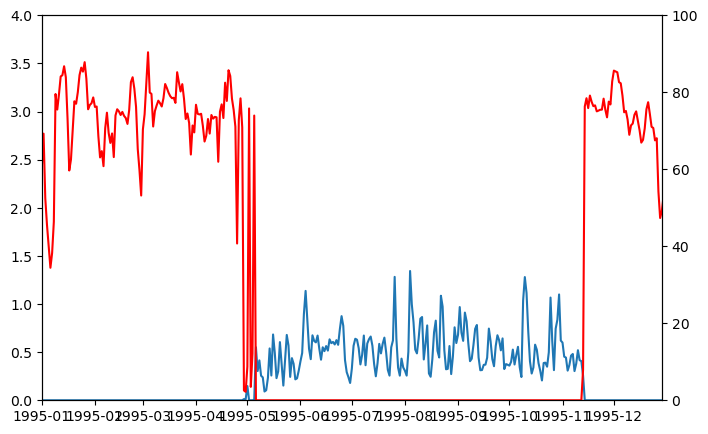

In [86]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes()
ax2 = ax.twinx()
year_to_plot = 1995
start,end = pd.to_datetime(f"{year_to_plot}-01-01"), pd.to_datetime(f"{year_to_plot}-12-29")
ax.plot(idx_daily, hs_daily[:,110000])
ax2.plot(idx_daily, ice_daily[:,110000], 'r')
ax.set_ylim(0,4),ax.set_xlim(start,end)
ax2.set_ylim(0,100),ax2.set_xlim(start,end)
plt.show()


In [11]:
idx = pd.to_datetime(times)
df_hs   = pd.DataFrame(hs,    index=idx)
idx = pd.to_datetime(time_ice)
df_ice  = pd.DataFrame(iceaf, index=idx)

# daily averages
df_hs  = df_hs.resample("1D").mean()
df_ice = df_ice.resample("1D").mean()

In [12]:
hs_daily    = df_hs.values            # (Td, N)
ice_daily   = df_ice.values           # (Td, N)
idx_daily   = df_hs.index.to_numpy()  # (Td,)

In [13]:
HS_THR  = 0.05   # m
ICE_THR = 20.0   # %
years_d = np.array(sorted(pd.to_datetime(idx_daily).year.unique()), dtype=int)
N_d     = np.arange(hs_daily.shape[1])

# --- compute onset/end/duration on daily data (original logic preserved) ---
records_daily = []
for j in N_d[:]:
    for yr in years_d:
        mask_d = (pd.to_datetime(idx_daily).year == yr)
        cond_d = (hs_daily[mask_d, j] > HS_THR) & (ice_daily[mask_d, j] < ICE_THR)

        if not cond_d.any():
            records_daily.append({
                "node": keep_idx[j],
                "year": int(yr),
                "onset_date": pd.NaT,
                "end_date": pd.NaT,
                "duration_days": np.nan,
                "lat": y_all[j],
                "lon": x_all[j],
            })
            continue

        inds_d = np.where(cond_d)[0]
        s_idx_d, e_idx_d = int(inds_d[0]), int(inds_d[-1])
        onset_d = pd.Timestamp(idx_daily[mask_d][s_idx_d])
        end_d   = pd.Timestamp(idx_daily[mask_d][e_idx_d])
        dur_d   = (end_d - onset_d).days + 1
        # waves all year (daily)
        if cond_d.all():
            dur_d = 366 if pd.Timestamp(yr, 12, 31).is_leap_year else 365
            onset_d, end_d = pd.NaT, pd.NaT

        records_daily.append({
            "node": keep_idx[j],
            "year": int(yr),
            "onset_date": onset_d,
            "end_date": end_d,
            "duration_days": dur_d,
            "lat": y_all[j],
            "lon": x_all[j],
        })

df_season = (pd.DataFrame.from_records(records_daily)
                   .sort_values(["node","year"])
                   .reset_index(drop=True))

print(df_season.head())

    node  year onset_date   end_date  duration_days        lat         lon
0  25006  1980 1980-01-01 1980-12-31          366.0  58.970392 -156.982437
1  25006  1981 1981-01-01 1981-12-31          365.0  58.970392 -156.982437
2  25006  1982 1982-01-01 1982-12-30          364.0  58.970392 -156.982437
3  25006  1983 1983-01-01 1983-12-22          356.0  58.970392 -156.982437
4  25006  1984 1984-01-01 1984-12-31          366.0  58.970392 -156.982437


In [14]:
df_season.to_csv("hs_seasonal_daily.csv", index=False)

In [48]:
def _rolling_nanmean_1d(x, w):
    x = np.asarray(x, float); m = np.isfinite(x)
    k = np.ones(int(w), float)
    s = np.convolve(np.where(m, x, 0.0), k, mode="same")
    c = np.convolve(m.astype(float), k, mode="same")
    return s / np.maximum(c, 1.0)

def _fill_small_gaps(mask, gap):
    if gap <= 0 or mask.size == 0: return mask
    m = mask.copy()
    ch = np.r_[True, m[1:] != m[:-1], True]
    pos = np.flatnonzero(ch); ln = np.diff(pos); vl = m[pos[:-1]]
    for i in range(len(ln)):
        if (not vl[i]) and (ln[i] <= gap):
            if i > 0 and i < len(ln)-1 and vl[i-1] and vl[i+1]:
                m[pos[i]:pos[i]+ln[i]] = True
    return m

def _longest_run(mask):
    if mask.size == 0 or not mask.any(): return None
    ch = np.r_[True, mask[1:] != mask[:-1], True]
    pos = np.flatnonzero(ch); ln = np.diff(pos); vl = mask[pos[:-1]]
    t = np.flatnonzero(vl)
    if t.size == 0: return None
    k = t[np.argmax(ln[t])]
    return int(pos[k]), int(pos[k] + ln[k] - 1)

# --- ICE-FIRST season (SIC primary, Hs secondary) -----------------------------
def compute_wave_season_ice_first(
    daily: pd.DataFrame,                 # Hs daily mean [time x nodes]
    years_arr: np.ndarray,               # years to evaluate
    sic_daily: pd.DataFrame,             # SIC [%] daily mean [time x nodes]
    # sea-ice controls
    ice_open_thresh_pct: float = 10.0,   # <10% => open water
    ice_gap: int = 5,                    # fill brief re-freeze gaps
    perennial_open_frac: float = 0.65,   # >=65% open across valid days => perennial
    min_season_days: int = 30,           # reject too-short seasons
    # wave confirmation (within open-water window only)
    roll_days: int = 7,                  # smooth Hs for stability
    eps_floor: float = 0.01,             # ~zero Hs floor (m)
    pct_within_open: float = 0.50,       # percentile of smoothed Hs within open-window
    trim_tail_frac_lo: float = 0.20,     # trim leading portion where Hs below open pctl
    trim_tail_frac_hi: float = 0.20,     # trim trailing portion where Hs below open pctl
    frac_above_eps_in_run: float = 0.50  # require at least this fraction >= eps within final run
) -> pd.DataFrame:
    # align by time intersection and column count
    idx = daily.index.intersection(sic_daily.index)
    daily = daily.reindex(idx)
    sic_daily = sic_daily.reindex(idx)
    if daily.shape[1] != sic_daily.shape[1]:
        n = min(daily.shape[1], sic_daily.shape[1])
        daily = daily.iloc[:, :n]; sic_daily = sic_daily.iloc[:, :n]

    doy = idx.dayofyear.to_numpy()
    yrs = idx.year.to_numpy()
    edges = np.flatnonzero(np.r_[True, yrs[1:] != yrs[:-1], True])
    yr_slices = {int(yrs[edges[k]]): (int(edges[k]), int(edges[k+1])) for k in range(len(edges)-1)}

    V = daily.to_numpy()      # Hs
    I = sic_daily.to_numpy()  # SIC%
    N = V.shape[1]
    out = []

    for j in range(N):
        hs_col, sic_col = V[:, j], I[:, j]
        for yr in years_arr:
            s_e = yr_slices.get(int(yr))
            if s_e is None:
                out.append({"node": j, "year": int(yr),
                            "onset_date": pd.NaT, "end_date": pd.NaT,
                            "duration_days": np.nan,
                            "onset_doy": np.nan, "end_doy": np.nan,
                            "perennial": False})
                continue

            s, e = s_e
            hs, sic = hs_col[s:e], sic_col[s:e]
            vhs, vsic = np.isfinite(hs), np.isfinite(sic)
            if vhs.sum() == 0 or vsic.sum() == 0:
                out.append({"node": j, "year": int(yr),
                            "onset_date": pd.NaT, "end_date": pd.NaT,
                            "duration_days": np.nan,
                            "onset_doy": np.nan, "end_doy": np.nan,
                            "perennial": False})
                continue

            # 1) OPEN-WATER by SIC (primary)
            open_mask = np.isfinite(sic) & (sic < ice_open_thresh_pct)
            open_mask = _fill_small_gaps(open_mask, ice_gap)

            inv = np.isfinite(sic)
            n_inv = int(inv.sum())
            if n_inv == 0:
                out.append({"node": j, "year": int(yr),
                            "onset_date": pd.NaT, "end_date": pd.NaT,
                            "duration_days": np.nan,
                            "onset_doy": np.nan, "end_doy": np.nan,
                            "perennial": False})
                continue

            frac_open = open_mask.sum() / n_inv
            if frac_open >= perennial_open_frac:
                # Perennial open-water: use full valid span
                g_s = s + int(np.flatnonzero(inv)[0]); g_e = s + int(np.flatnonzero(inv)[-1])
                onset, end = idx[g_s], idx[g_e]
                length = int((end - onset).days + 1)
                out.append({"node": j, "year": int(yr),
                            "onset_date": onset, "end_date": end,
                            "duration_days": length,
                            "onset_doy": int(doy[g_s]), "end_doy": int(doy[g_e]),
                            "perennial": True})
                continue

            cand = _longest_run(open_mask)
            if cand is None:
                out.append({"node": j, "year": int(yr),
                            "onset_date": pd.NaT, "end_date": pd.NaT,
                            "duration_days": np.nan,
                            "onset_doy": np.nan, "end_doy": np.nan,
                            "perennial": False})
                continue

            a, b = cand  # candidate open-water season indices (year-local)

            # 2) WAVE CONFIRMATION (secondary) within open-water window only
            sm_hs = _rolling_nanmean_1d(hs, roll_days)
            ow_sm = sm_hs[a:b+1]
            ow_hs = hs[a:b+1]
            ow_valid = np.isfinite(ow_sm)

            if ow_valid.sum() == 0:
                out.append({"node": j, "year": int(yr),
                            "onset_date": pd.NaT, "end_date": pd.NaT,
                            "duration_days": np.nan,
                            "onset_doy": np.nan, "end_doy": np.nan,
                            "perennial": False})
                continue

            thr_ow = max(np.nanpercentile(ow_sm, pct_within_open * 100.0), eps_floor)
            wave_mask = (ow_sm >= thr_ow) & ow_valid

            # Optional trimming: drop low-wave tails at both ends
            # Compute contiguous True run after trimming a fraction of ends where wave_mask is mostly False
            wm = wave_mask.copy()
            L = wm.size
            trim_lo = int(np.floor(L * trim_tail_frac_lo))
            trim_hi = int(np.floor(L * trim_tail_frac_hi))
            if trim_lo > 0:
                # push start forward while leading block has few Trues
                k = 0
                while k < trim_lo and k < L and not wm[k]:
                    k += 1
                if k > 0: wm[:k] = False
            if trim_hi > 0:
                k = 0
                while k < trim_hi and k < L and not wm[-(k+1)]:
                    k += 1
                if k > 0: wm[L-k:] = False

            final_mask = _fill_small_gaps(wm, gap=3)  # small continuity boost inside open water
            final_run = _longest_run(final_mask)

            if final_run is None:
                out.append({"node": j, "year": int(yr),
                            "onset_date": pd.NaT, "end_date": pd.NaT,
                            "duration_days": np.nan,
                            "onset_doy": np.nan, "end_doy": np.nan,
                            "perennial": False})
                continue

            fa, fb = final_run
            # map back to year indices
            A, B = a + fa, a + fb

            # 3) Final guards
            g_s, g_e = s + A, s + B
            onset, end = idx[g_s], idx[g_e]
            length = int((end - onset).days + 1)
            if length < min_season_days:
                out.append({"node": j, "year": int(yr),
                            "onset_date": pd.NaT, "end_date": pd.NaT,
                            "duration_days": np.nan,
                            "onset_doy": np.nan, "end_doy": np.nan,
                            "perennial": False})
                continue

            run_hs = hs[A:B+1]
            if (np.isfinite(run_hs) & (run_hs >= eps_floor)).sum() < int(frac_above_eps_in_run * run_hs.size):
                out.append({"node": j, "year": int(yr),
                            "onset_date": pd.NaT, "end_date": pd.NaT,
                            "duration_days": np.nan,
                            "onset_doy": np.nan, "end_doy": np.nan,
                            "perennial": False})
                continue

            out.append({"node": j, "year": int(yr),
                        "onset_date": onset, "end_date": end,
                        "duration_days": length,
                        "onset_doy": int(doy[g_s]), "end_doy": int(doy[g_e]),
                        "perennial": False})

    return (pd.DataFrame(out)
              .sort_values(["node","year"])
              .reset_index(drop=True))

In [51]:
years_arr = np.arange(1980, 2025)
df_season = compute_wave_season_ice_first(
    daily,         # daily Hs DataFrame [time x nodes]
    years_arr,     # e.g., np.arange(1980, 2025)
    sic_daily,     # daily SIC% DataFrame [time x nodes]
    ice_open_thresh_pct=20.0,   # <10% sea ice = open water
    min_season_days=15,         # reject too-short seasons
    pct_within_open=0.50,       # wave confirmation inside open-water window
)
df_season["lon"] = df_season["node"].map(lambda j: x_all[j])
df_season["lat"] = df_season["node"].map(lambda j: y_all[j])
df_season.to_csv("hs_seasonal_v3.csv", index=False)

In [8]:
def _rolling_nanmean_1d(x, w):
    x = np.asarray(x, float); m = np.isfinite(x)
    k = np.ones(int(w), float)
    s = np.convolve(np.where(m, x, 0.0), k, mode="same")
    c = np.convolve(m.astype(float), k, mode="same")
    return s / np.maximum(c, 1.0)

def _fill_small_gaps(mask, gap):
    if gap <= 0 or mask.size == 0: return mask
    m = mask.copy()
    ch = np.r_[True, m[1:] != m[:-1], True]
    pos = np.flatnonzero(ch); ln = np.diff(pos); vl = m[pos[:-1]]
    for i in range(len(ln)):
        if (not vl[i]) and (ln[i] <= gap):
            if i > 0 and i < len(ln)-1 and vl[i-1] and vl[i+1]:
                m[pos[i]:pos[i]+ln[i]] = True
    return m

def _longest_run(mask):
    if mask.size == 0 or not mask.any(): return None
    ch = np.r_[True, mask[1:] != mask[:-1], True]
    pos = np.flatnonzero(ch); ln = np.diff(pos); vl = mask[pos[:-1]]
    t = np.flatnonzero(vl)
    if t.size == 0: return None
    k = t[np.argmax(ln[t])]
    return int(pos[k]), int(pos[k] + ln[k] - 1)

def compute_wave_season_with_ice_pct(
    daily: pd.DataFrame,
    years_arr: np.ndarray,
    sic_daily: pd.DataFrame,              # SIC [%], same shape/index/columns as daily
    pct_onset: float = 0.60,              # seasonal, not storm-only
    roll_days: int = 7,                   # smooth Hs
    gap_max: int = 7,                     # fill short Hs gaps
    eps_floor: float = 0.01,              # ~zero Hs floor (m)
    perennial_min_frac: float = 0.65,     # ≥65% True => perennial
    ice_open_thresh_pct: float = 10.0,    # <10% SIC considered open water
    ice_gap: int = 5,                     # allow short re-freeze blips
    min_season_days: int = 30,            # reject too-short seasons
    amp_min: float = 0.05,                # median smoothed Hs within run
    frac_above_eps_in_run: float = 0.70,  # persistence in raw Hs
    min_open_frac_in_run: float = 0.80    # persistence in open-water
) -> pd.DataFrame:
    # align by time (intersection) and ensure consistent columns count
    idx = daily.index.intersection(sic_daily.index)
    daily = daily.reindex(idx)
    sic_daily = sic_daily.reindex(idx)
    if daily.shape[1] != sic_daily.shape[1]:
        n = min(daily.shape[1], sic_daily.shape[1])
        daily = daily.iloc[:, :n]; sic_daily = sic_daily.iloc[:, :n]

    doy = idx.dayofyear.to_numpy()
    yrs = idx.year.to_numpy()
    edges = np.flatnonzero(np.r_[True, yrs[1:] != yrs[:-1], True])
    yr_slices = {int(yrs[edges[k]]): (int(edges[k]), int(edges[k+1])) for k in range(len(edges)-1)}

    V = daily.to_numpy()        # Hs [days x nodes]
    I = sic_daily.to_numpy()    # SIC% [days x nodes]
    N = V.shape[1]
    out = []

    for j in range(N):
        hs_col, sic_col = V[:, j], I[:, j]
        for yr in years_arr:
            s_e = yr_slices.get(int(yr))
            if s_e is None:
                out.append({"node": j, "year": int(yr),
                            "onset_date": pd.NaT, "end_date": pd.NaT,
                            "duration_days": np.nan,
                            "onset_doy": np.nan, "end_doy": np.nan,
                            "threshold_m": np.nan, "perennial": False})
                continue

            s, e = s_e
            hs, sic = hs_col[s:e], sic_col[s:e]
            vhs, vsic = np.isfinite(hs), np.isfinite(sic)
            if vhs.sum() == 0 or vsic.sum() == 0:
                out.append({"node": j, "year": int(yr),
                            "onset_date": pd.NaT, "end_date": pd.NaT,
                            "duration_days": np.nan,
                            "onset_doy": np.nan, "end_doy": np.nan,
                            "threshold_m": np.nan, "perennial": False})
                continue

            sm_hs = _rolling_nanmean_1d(hs, roll_days)
            thr = max(float(np.nanpercentile(sm_hs, pct_onset * 100.0)), eps_floor)

            open_mask = np.isfinite(sic) & (sic < ice_open_thresh_pct)      # SIC% < 10
            open_mask = _fill_small_gaps(open_mask, ice_gap)

            hs_mask = np.isfinite(sm_hs) & (sm_hs >= thr)
            mask = _fill_small_gaps(hs_mask & open_mask, gap_max)

            inv = np.isfinite(sm_hs) & np.isfinite(sic)
            n_inv = int(inv.sum())
            frac_true = (mask.sum() / n_inv) if n_inv > 0 else 0.0

            if n_inv > 0 and frac_true >= perennial_min_frac:
                g_s = s + int(np.flatnonzero(inv)[0]); g_e = s + int(np.flatnonzero(inv)[-1])
                onset, end = idx[g_s], idx[g_e]
                length = int((end - onset).days + 1)
                out.append({"node": j, "year": int(yr),
                            "onset_date": onset, "end_date": end,
                            "duration_days": length,
                            "onset_doy": int(doy[g_s]), "end_doy": int(doy[g_e]),
                            "threshold_m": thr, "perennial": True})
                continue

            run = _longest_run(mask)
            if run is None:
                out.append({"node": j, "year": int(yr),
                            "onset_date": pd.NaT, "end_date": pd.NaT,
                            "duration_days": np.nan,
                            "onset_doy": np.nan, "end_doy": np.nan,
                            "threshold_m": thr, "perennial": False})
                continue

            a, b = run
            g_s, g_e = s + a, s + b
            onset, end = idx[g_s], idx[g_e]
            length = int((end - onset).days + 1)

            run_hs, run_sm, run_sic = hs[a:b+1], sm_hs[a:b+1], sic[a:b+1]
            med_amp_ok   = (np.nanmedian(run_sm) >= amp_min)
            frac_eps_ok  = (np.isfinite(run_hs) & (run_hs >= eps_floor)).sum() >= int(frac_above_eps_in_run * run_hs.size)
            open_frac_ok = (np.isfinite(run_sic) & (run_sic < ice_open_thresh_pct)).sum() >= int(min_open_frac_in_run * run_sic.size)
            length_ok    = (length >= min_season_days)

            if not (med_amp_ok and frac_eps_ok and open_frac_ok and length_ok):
                out.append({"node": j, "year": int(yr),
                            "onset_date": pd.NaT, "end_date": pd.NaT,
                            "duration_days": np.nan,
                            "onset_doy": np.nan, "end_doy": np.nan,
                            "threshold_m": thr, "perennial": False})
                continue

            out.append({"node": j, "year": int(yr),
                        "onset_date": onset, "end_date": end,
                        "duration_days": length,
                        "onset_doy": int(doy[g_s]), "end_doy": int(doy[g_e]),
                        "threshold_m": thr, "perennial": False})

    return (pd.DataFrame(out)
              .sort_values(["node","year"])
              .reset_index(drop=True))

In [9]:
years_arr = np.arange(1980, 2025)
df_season = compute_wave_season_with_ice_pct(
    daily,         # daily Hs DataFrame
    years_arr,     # e.g., np.arange(1980, 2025)
    sic_daily,     # daily sea ice concentration [%]
    pct_onset=0.60,      # season-defining percentile (tune 0.5–0.7)
    roll_days=7,         # smooth Hs
    gap_max=7,           # fill short Hs gaps
    ice_open_thresh_pct=5.0,  # <10% ice = open water
    min_season_days=5,  # discard runs shorter than this
)


In [10]:
df_season["lon"] = df_season["node"].map(lambda j: x_all[j])
df_season["lat"] = df_season["node"].map(lambda j: y_all[j])

In [11]:
df_season.to_csv("hs_seasonal_v2.csv", index=False)

In [6]:
df_season = pd.read_csv("hs_seasonal_v2.csv")#, parse_dates=["onset_date","end_date"])

In [50]:
df_season

,node,year,onset_date,end_date,duration_days,onset_doy,end_doy,perennial,lon,lat
0,0,1980,1980-01-01,1980-12-31,366.0,1.0,366.0,True,-158.058943,58.944763
1,0,1981,1981-01-01,1981-12-31,365.0,1.0,365.0,True,-158.058943,58.944763
2,0,1982,1982-01-01,1982-12-31,365.0,1.0,365.0,True,-158.058943,58.944763
3,0,1983,1983-01-01,1983-12-31,365.0,1.0,365.0,True,-158.058943,58.944763
4,0,1984,1984-01-01,1984-12-31,366.0,1.0,366.0,True,-158.058943,58.944763
...,...,...,...,...,...,...,...,...,...,...
11259760,250216,2020,2020-01-01,2020-12-31,366.0,1.0,366.0,True,-160.249603,66.411408
11259761,250216,2021,2021-01-01,2021-12-31,365.0,1.0,365.0,True,-160.249603,66.411408
11259762,250216,2022,2022-01-01,2022-12-31,365.0,1.0,365.0,True,-160.249603,66.411408
11259763,250216,2023,2023-01-01,2023-12-31,365.0,1.0,365.0,True,-160.249603,66.411408


In [23]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
import cartopy as cart

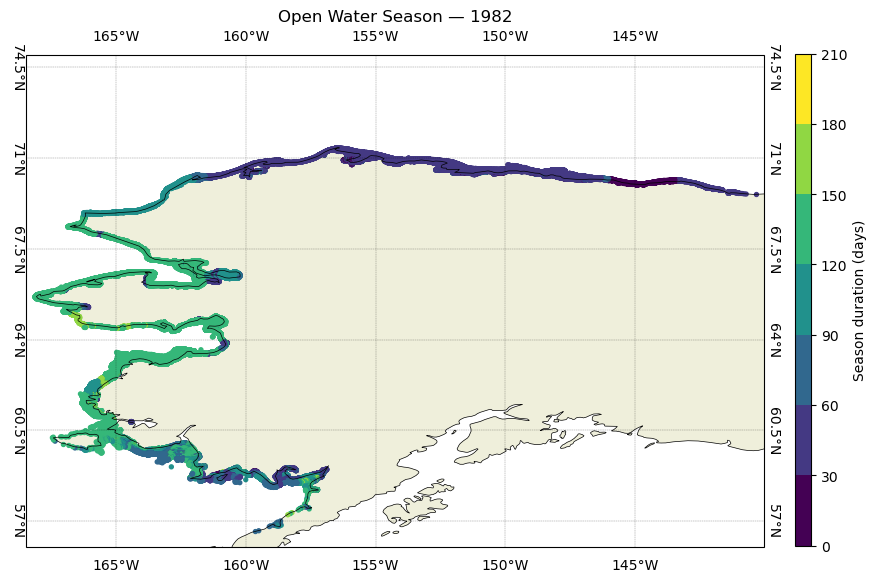

In [45]:
year_to_plot = 1982
N = len(x_all)
dur = np.full(N, np.nan, dtype=float)

sub = df_season.loc[df_season["year"] == year_to_plot, ["node", "duration_days"]]
if not sub.empty:
    last = (
        sub.dropna(subset=["duration_days"])
        .sort_values("node")
        .drop_duplicates("node", keep="last")
    )
    dur[last["node"].values.astype(int)] = last["duration_days"].values.astype(float)

# --- subset nodes ---
idx = keep_idx  # or np.arange(N)
xx, yy, zz = x_all, y_all, dur

# --- define bins and norm (set min/max here, not in scatter) ---
#bins = [0, 30, 60, 90, 120, 150, 180]  # example bins
bins = np.arange(0,215,30)
cmap    = plt.get_cmap('viridis', len(bins)-1)
norm = BoundaryNorm(bins, len(bins)-1)# ncolors=cmap, clip=False)

# --- plot ---
crs_data = ccrs.PlateCarree()
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=crs_data)

if bbox is not None:
    ax.set_extent([bbox[0], bbox[1], bbox[2], bbox[3]], crs=crs_data)

ax.add_feature(cfeature.LAND, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

gl = ax.gridlines(xlocs=np.arange(-190, -100, 5),
                  ylocs=np.arange(-90, 90, 3.5),
                  draw_labels=True, linewidth=0.3, color="black", alpha=0.5,
                  y_inline=False, linestyle="--", zorder=20)
gl.xlabels_top = False
gl.xlabels_bottom = True
gl.xlabel_style = {'rotation': 0}
gl.ylabels_left = False
gl.ylabels_right = True
gl.ylabel_style = {'rotation': -90}
gl.ypadding = 1.25
gl.xformatter = cart.mpl.gridliner.LONGITUDE_FORMATTER
gl.xpadding = 8
sc = ax.scatter(xx, yy, c=zz, s=8, cmap=cmap, norm=norm,
                transform=crs_data)

#cb = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.02, boundaries=bins, spacing="proportional")

cax = fig.add_axes([1., 0.075, 0.02, 0.82])
cb  = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cax, orientation='vertical',
    boundaries=bins, ticks=bins)
cb.set_label("Season duration (days)")
ax.set_title(f"Open Water Season — {year_to_plot}")
plt.tight_layout()
plt.savefig(f"/scratch/tmiesse/project/satellite/figures/hs_season_duration_{year_to_plot}.png", dpi=300)
plt.show()